# EDA — criminalite.csv
Score de Vivabilité · Statistiques de criminalité par commune (CODGEO)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130

## 1. Chargement

In [2]:
from pathlib import Path

BASE_DIR = Path.cwd().parents[0]
FILE = BASE_DIR / 'brute' / 'score_de_vivabilité' / 'criminalite.csv'

df = pd.read_csv(FILE, sep=None, engine='python')
df.columns = df.columns.str.strip().str.replace('\ufeff', '', regex=False)
print(f'Shape : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
df.head()

Shape : (5238000, 13)
Colonnes : ['CODGEO_2025', 'annee', 'indicateur', 'unite_de_compte', 'nombre', 'taux_pour_mille', 'est_diffuse', 'insee_pop', 'insee_pop_millesime', 'insee_log', 'insee_log_millesime', 'complement_info_nombre', 'complement_info_taux']


,CODGEO_2025,annee,indicateur,unite_de_compte,nombre,taux_pour_mille,est_diffuse,insee_pop,insee_pop_millesime,insee_log,insee_log_millesime,complement_info_nombre,complement_info_taux
0,01001,2016,Violences physiques intrafamiliales,Victime,0.0,"0,0000000",diff,767,2016,348,2016,NaN,NaN
1,01001,2016,Violences physiques hors cadre familial,Victime,NaN,NaN,ndiff,767,2016,348,2016,"1,3620690","0,9598386"
2,01001,2016,Violences sexuelles,Victime,0.0,"0,0000000",diff,767,2016,348,2016,NaN,NaN
3,01001,2016,Vols avec armes,Infraction,0.0,"0,0000000",diff,767,2016,348,2016,NaN,NaN
4,01001,2016,Vols violents sans arme,Infraction,0.0,"0,0000000",diff,767,2016,348,2016,NaN,NaN


## 2. Infos générales

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5238000 entries, 0 to 5237999
Data columns (total 13 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   CODGEO_2025             str    
 1   annee                   int64  
 2   indicateur              str    
 3   unite_de_compte         str    
 4   nombre                  float64
 5   taux_pour_mille         str    
 6   est_diffuse             str    
 7   insee_pop               int64  
 8   insee_pop_millesime     int64  
 9   insee_log               int64  
 10  insee_log_millesime     int64  
 11  complement_info_nombre  str    
 12  complement_info_taux    str    
dtypes: float64(1), int64(5), str(7)
memory usage: 825.0 MB


In [4]:
df.describe(include='all')

,CODGEO_2025,annee,indicateur,unite_de_compte,nombre,taux_pour_mille,est_diffuse,insee_pop,insee_pop_millesime,insee_log,insee_log_millesime,complement_info_nombre,complement_info_taux
count,5238000,5.238000e+06,5238000,5238000,2.812461e+06,2811612,5238000,5.238000e+06,5.238000e+06,5.238000e+06,5.238000e+06,2425539,2425539
unique,34920,NaN,15,5,NaN,238613,2,NaN,NaN,NaN,NaN,10092,14345
top,01001,NaN,Violences physiques intrafamiliales,Victime,NaN,"0,0000000",diff,NaN,NaN,NaN,NaN,"1,0000000","4,5477973"
freq,150,NaN,349200,1396800,NaN,2374266,2812461,NaN,NaN,NaN,NaN,7018,671
mean,NaN,2.020500e+03,NaN,NaN,1.119211e+01,NaN,NaN,2.036506e+03,2.020198e+03,1.118476e+03,2.019899e+03,NaN,NaN
std,NaN,2.872282e+00,NaN,NaN,2.788777e+02,NaN,NaN,1.540258e+04,2.482335e+00,9.485172e+03,2.166059e+00,NaN,NaN
min,NaN,2.016000e+03,NaN,NaN,0.000000e+00,NaN,NaN,0.000000e+00,2.016000e+03,0.000000e+00,2.016000e+03,NaN,NaN
25%,NaN,2.018000e+03,NaN,NaN,0.000000e+00,NaN,NaN,1.980000e+02,2.018000e+03,1.200000e+02,2.018000e+03,NaN,NaN
50%,NaN,2.020500e+03,NaN,NaN,0.000000e+00,NaN,NaN,4.600000e+02,2.020000e+03,2.550000e+02,2.020000e+03,NaN,NaN
75%,NaN,2.023000e+03,NaN,NaN,0.000000e+00,NaN,NaN,1.172000e+03,2.023000e+03,6.200000e+02,2.022000e+03,NaN,NaN


## 3. Valeurs manquantes — critique pour ce dataset

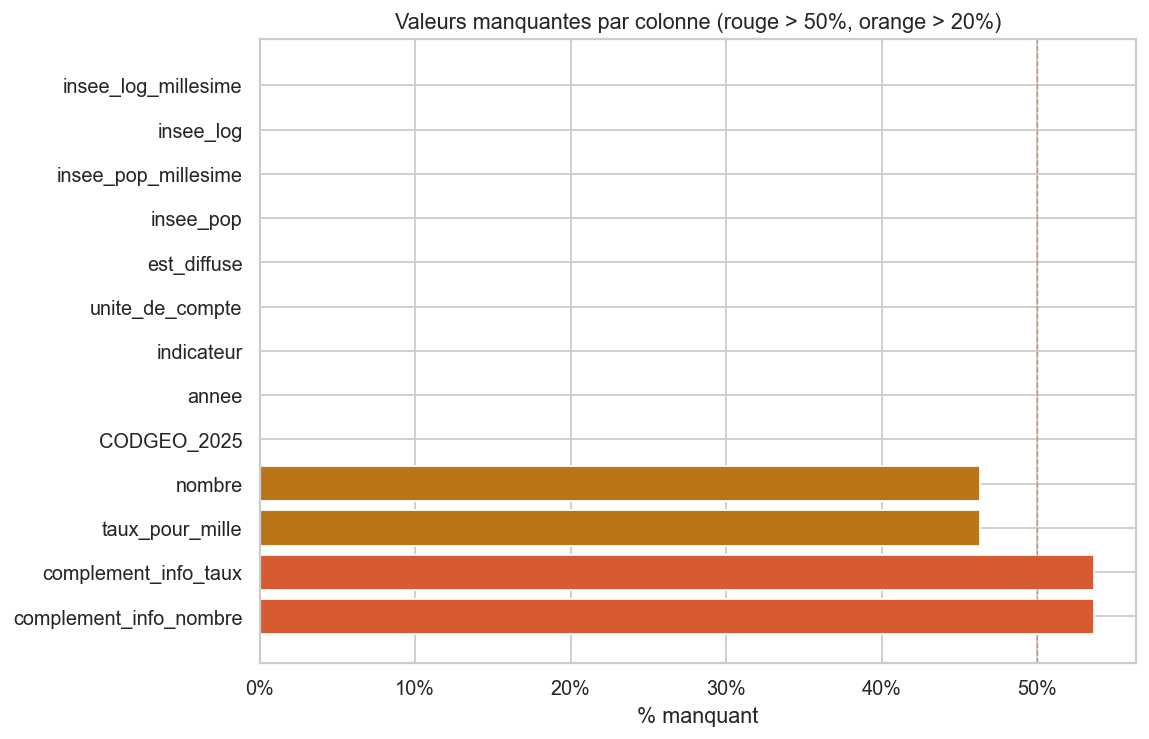

,% manquant
complement_info_nombre,53.693414
complement_info_taux,53.693414
taux_pour_mille,46.322795
nombre,46.306586
CODGEO_2025,0.000000
annee,0.000000
indicateur,0.000000
unite_de_compte,0.000000
est_diffuse,0.000000
insee_pop,0.000000


In [5]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, max(3, len(df.columns) * 0.45)))
colors = ['#D85A30' if v > 50 else '#BA7517' if v > 20 else '#1D9E75' for v in missing.values]
ax.barh(missing.index, missing.values, color=colors)
ax.set_xlabel('% manquant')
ax.set_title('Valeurs manquantes par colonne (rouge > 50%, orange > 20%)')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.axvline(50, color='#D85A30', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

display(missing.rename('% manquant').to_frame())

## 4. Doublons

In [6]:
n_dup = df.duplicated().sum()
print(f'Doublons : {n_dup} ({n_dup/len(df)*100:.2f}%)')
if n_dup > 0:
    display(df[df.duplicated(keep=False)].head(10))

Doublons : 0 (0.00%)


## 5. Détection colonnes clés

In [7]:
def find_col(df, *keywords):
    for kw in keywords:
        match = [c for c in df.columns if kw.lower() in c.lower()]
        if match: return match[0]
    return None

col_map = {
    'codgeo'      : find_col(df, 'codgeo', 'insee', 'code_commune'),
    'annee'       : find_col(df, 'annee', 'année', 'year'),
    'indicateur'  : find_col(df, 'indicateur', 'type', 'categorie'),
    'nombre'      : find_col(df, 'nombre', 'count', 'nb'),
    'taux'        : find_col(df, 'taux', 'rate', 'pour_mille'),
    'diffuse'     : find_col(df, 'diffuse', 'diffusé', 'est_diff'),
    'unite'       : find_col(df, 'unite', 'unité', 'unit'),
}

print('Colonnes détectées :')
for k, v in col_map.items():
    status = '✅' if v else '❌'
    print(f'  {status}  {k:20s} → {v}')
print(f'\nColonnes non mappées : {[c for c in df.columns if c not in col_map.values()]}')

Colonnes détectées :
  ✅  codgeo               → CODGEO_2025
  ✅  annee                → annee
  ✅  indicateur           → indicateur
  ✅  nombre               → nombre
  ✅  taux                 → taux_pour_mille
  ✅  diffuse              → est_diffuse
  ✅  unite                → unite_de_compte

Colonnes non mappées : ['insee_pop', 'insee_pop_millesime', 'insee_log', 'insee_log_millesime', 'complement_info_nombre', 'complement_info_taux']


## 6. Données diffusées vs non diffusées

est_diffuse
diff     2812461
ndiff    2425539


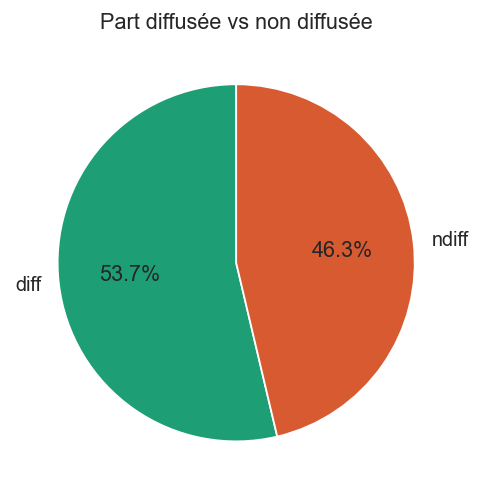

In [8]:
diff_col = col_map['diffuse']
if diff_col:
    vc = df[diff_col].value_counts()
    print(vc.to_string())

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.pie(vc.values, labels=vc.index, autopct='%1.1f%%',
           colors=['#1D9E75', '#D85A30'], startangle=90)
    ax.set_title('Part diffusée vs non diffusée')
    plt.tight_layout()
    plt.show()
else:
    print('❌ Colonne diffuse non trouvée')

## 7. Répartition par type d'indicateur

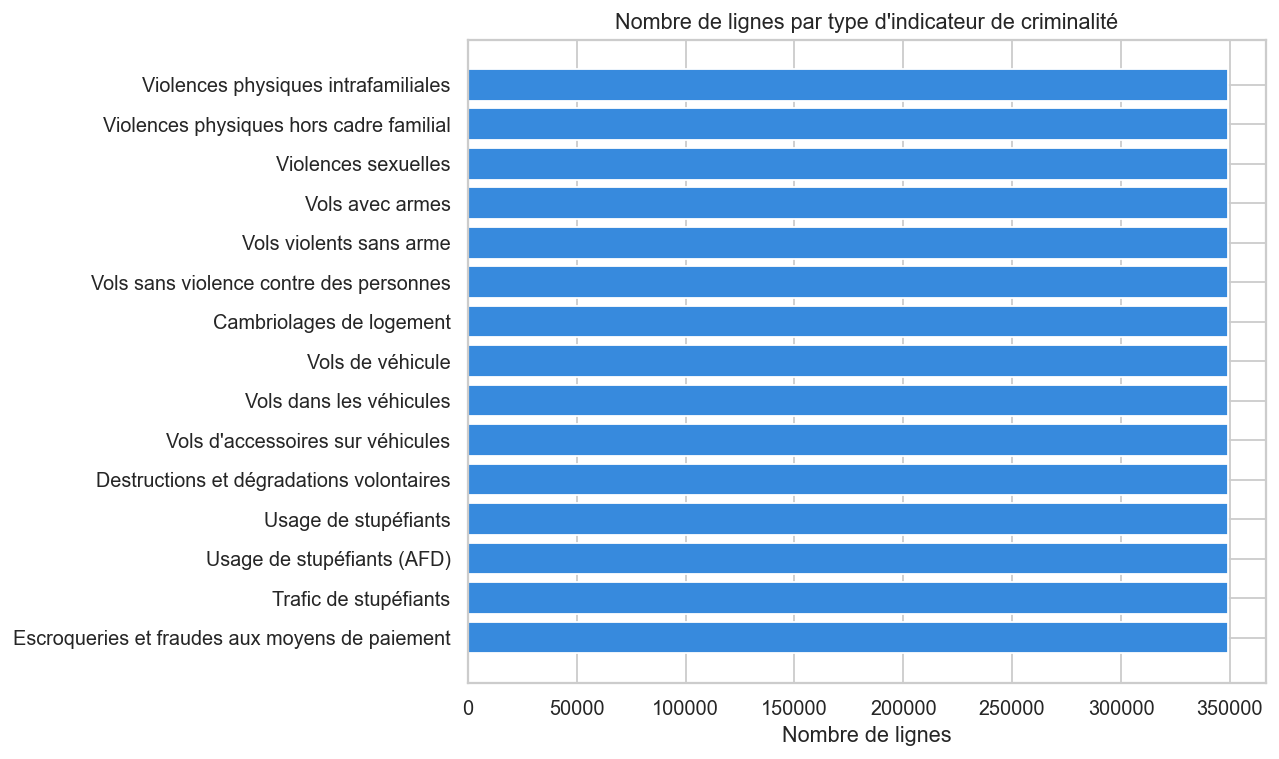

,count
indicateur,
Violences physiques intrafamiliales,349200
Violences physiques hors cadre familial,349200
Violences sexuelles,349200
Vols avec armes,349200
Vols violents sans arme,349200
Vols sans violence contre des personnes,349200
Cambriolages de logement,349200
Vols de véhicule,349200
Vols dans les véhicules,349200


In [9]:
ind_col = col_map['indicateur']
if ind_col:
    vc_ind = df[ind_col].value_counts()
    fig, ax = plt.subplots(figsize=(10, max(4, len(vc_ind) * 0.4)))
    ax.barh(vc_ind.index, vc_ind.values, color='#378ADD')
    ax.set_title("Nombre de lignes par type d'indicateur de criminalité")
    ax.set_xlabel('Nombre de lignes')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    display(vc_ind.rename('count').to_frame())

## 8. Distribution du nombre de faits (données diffusées)

Lignes diffusées : 2,812,461


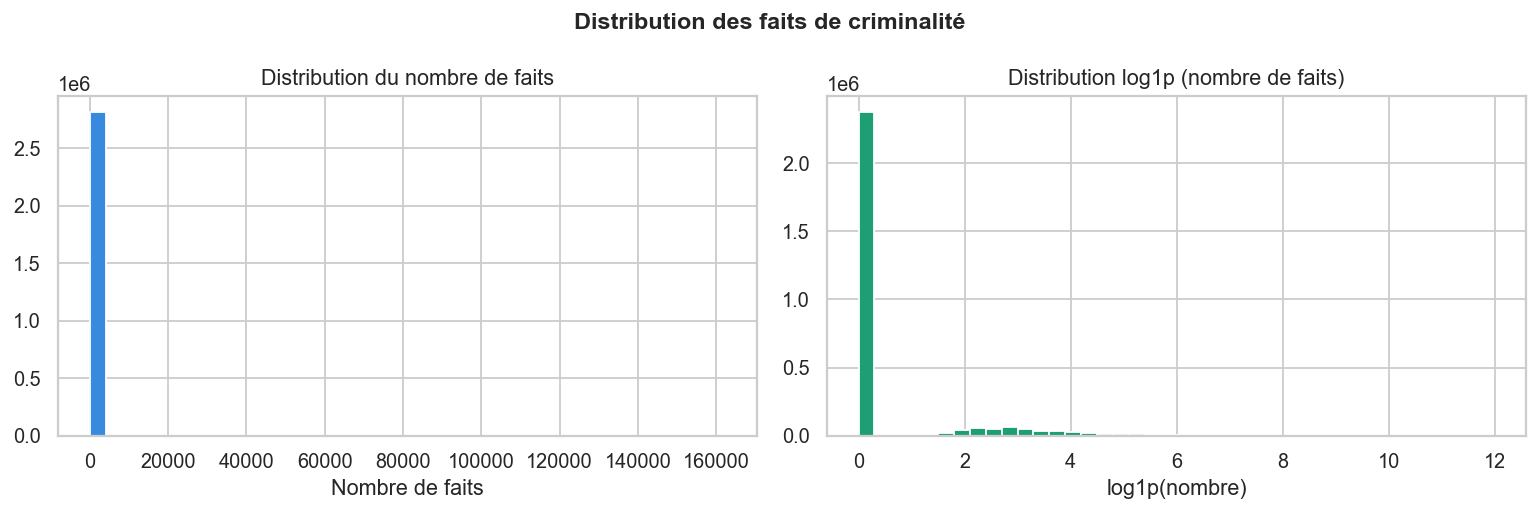

In [10]:
nombre_col = col_map['nombre']
diff_col   = col_map['diffuse']

df_diff = df[df[diff_col] == 'diff'].copy() if diff_col else df.copy()
print(f'Lignes diffusées : {len(df_diff):,}')

if nombre_col and df_diff[nombre_col].notna().sum() > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(df_diff[nombre_col].dropna(), bins=40, color='#378ADD', edgecolor='white')
    axes[0].set_title('Distribution du nombre de faits')
    axes[0].set_xlabel('Nombre de faits')

    axes[1].hist(np.log1p(df_diff[nombre_col].dropna()), bins=40, color='#1D9E75', edgecolor='white')
    axes[1].set_title('Distribution log1p (nombre de faits)')
    axes[1].set_xlabel('log1p(nombre)')

    plt.suptitle('Distribution des faits de criminalité', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 9. Top communes par volume de faits

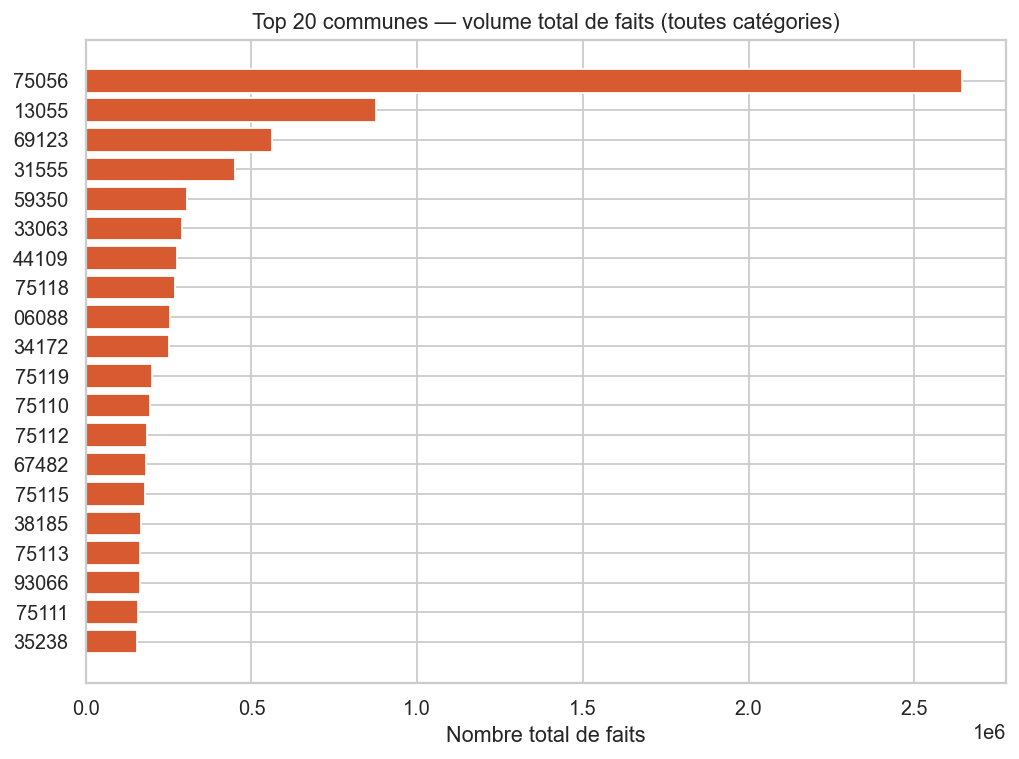

In [11]:
codgeo_col = col_map['codgeo']
nombre_col = col_map['nombre']

if codgeo_col and nombre_col:
    top_communes = (
        df_diff.groupby(codgeo_col)[nombre_col]
        .sum()
        .sort_values(ascending=False)
        .head(20)
    )
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top_communes.index.astype(str), top_communes.values, color='#D85A30')
    ax.set_title('Top 20 communes — volume total de faits (toutes catégories)')
    ax.set_xlabel('Nombre total de faits')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## 10. Résumé + plan Silver

In [12]:
print('=' * 55)
print('RÉSUMÉ EDA — criminalite.csv')
print('=' * 55)
print(f'  Lignes              : {len(df):,}')
print(f'  Colonnes            : {len(df.columns)}')
print(f'  Doublons            : {df.duplicated().sum()}')
if col_map['codgeo']:   print(f'  Communes (CODGEO)   : {df[col_map["codgeo"]].nunique()}')
if col_map['annee']:    print(f'  Année(s)            : {df[col_map["annee"]].unique()}')
if col_map['indicateur']: print(f'  Indicateurs         : {df[col_map["indicateur"]].nunique()}')
if diff_col:            print(f'  Lignes diffusées    : {(df[diff_col]=="diff").sum()} ({(df[diff_col]=="diff").mean()*100:.1f}%)')
print('=' * 55)
print()
print('ACTIONS SILVER REQUISES :')
print('  → Filtrer est_diffuse == "diff" avant tout calcul')
print('  → Convertir taux_pour_mille (str avec virgule) en float')
print('  → Pivoter indicateur → colonnes pour 1 ligne par CODGEO')
print('  → Utiliser taux_pour_mille (normalisé par pop) pour le score Gold')
print('  → ⚠️  Snapshot 2016 uniquement — donnée ancienne à signaler')

RÉSUMÉ EDA — criminalite.csv
  Lignes              : 5,238,000
  Colonnes            : 13
  Doublons            : 0
  Communes (CODGEO)   : 34920
  Année(s)            : [2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]
  Indicateurs         : 15
  Lignes diffusées    : 2812461 (53.7%)

ACTIONS SILVER REQUISES :
  → Filtrer est_diffuse == "diff" avant tout calcul
  → Convertir taux_pour_mille (str avec virgule) en float
  → Pivoter indicateur → colonnes pour 1 ligne par CODGEO
  → Utiliser taux_pour_mille (normalisé par pop) pour le score Gold
  → ⚠️  Snapshot 2016 uniquement — donnée ancienne à signaler
